# MASS

### Problems 

- Small prompt changes → huge performance swings
- Worse in multi-agent setups (errors compound)
- Too many ways to connect agents
- Prompts and topology are interdependent
- Optimizing both together is computationally hard 

- Not all topologies help (many degrade performance)
- Need to identify “useful” structures only

## APO - Automatic propmt optimization

-  APO becomes more complex due to the interdependence across agents

- Refinement
    - Agent generates an answer
    - Same (or another) agent reviews it
    - Improves it
    - Repeat
    - sometimes hurts performance (even –15%)


- Summarize
    - Multiple agents produce answers
    - A summarizer agent merges them into one
    - Important details get lost or diluted
    - Weak answers can pollute the final result

- Debate
    - Agent A gives an answer
    - Agent B critiques or challenges it
    - They go back and forth
    - Final answer is chosen after discussion

- How the debate happens:
    - Agent A (Proposer)
        - Generates an answer + reasoning
    - Agent B (Critic)
        - Is prompted to:
            - Find errors
            - Question assumptions
            - Point out missing steps
    - (Optional) Back-and-forth:
    - A defends or revises
    - B critiques again


- How it’s implemented 

    - It’s all done via prompt engineering:

    - Different roles

    - Proposer prompt

        - “Solve the problem step by step.”

    - Critic prompt

        - “Critically evaluate the solution. Identify flaws, inconsistencies, or incorrect assumptions.”

- Executor (Exe.)
    - One agent plans or reasons
    - Another agent executes (e.g., runs code, produces final output)
    - Implemented via prompts similarily as debate

- Good multi-agent designs are rare.
- Most possible topologies in the “design space” are: useless, or actively harmful
- Only a small subset (“influential set”) actually improves performance.

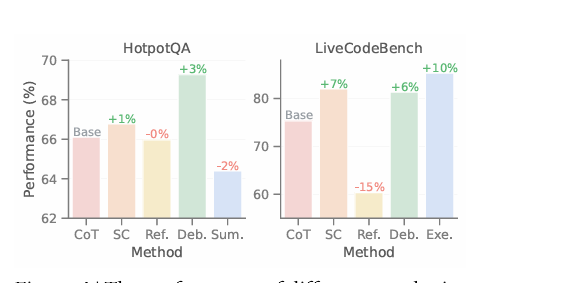

- Above figure shows only a small fraction of topoligies actually help 

- Score each building block (like debate, summarize, etc.)
- Keep the useful ones
- Ignore the bad ones (pruning)

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Topology:

- Topology refers to the structure of the multi-agent system—what components are used, how many agents are involved, and how they are connected (parallel, sequential, or mixed)—not just the order of operations.

1. Which building blocks are used
    - (summarize, reflect, debate, aggregate, execute)

2. How many of each
    - (e.g., 5 parallel agents, 2 debate rounds, etc.)

3. How they are connected
    - Sequential (chain)
    - Parallel (multiple agents at once)
    - Mixed (parallel + sequential)


--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Algorithm proposed in MAS

- Incremental Influence:
- 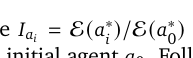

- a0 -->  base agent (Without topology)
- ai --> adding a specific building block (e.g., debate)
- E --> performance


### Step-1

- convert influence into a probability using Softmax
- 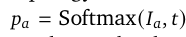
- Low-t  pick only best --> more pruning 
- High-t --> less pruning --> hyperparameter

### Step-2

- Sample random number: u∼Uniform(0,1)  --> generate random number between 0 and 1 
- If u > pa --> Reject the block (prune it) 

### Step-3

- Randomly build agent systems from it
- But with a constraint:

    #### N(a) < B

- N(a) --> no. of agents
- B --> max budjet 

- Instead of connecting randomly, reaserchers followed this order : 
- [summarize → reflect → debate → aggregate]

- The algorithm first learns which building blocks actually help, removes weak ones, and then searches for the best multi-agent workflow only within this smaller, high-quality space.

### Step-4 **Workflow-level prompt optimization**

- Instead of optimizing prompts for each agent separately,
you optimize all prompts together, considering how agents interact.

- Even if each agent is good individually:
    - They might not work well together

Because:
One agent’s output becomes another’s input
- Misalignment can happen between agents

- Workflow-level prompt optimization fine-tunes all agents together so they collaborate effectively within the chosen topology, rather than acting as isolated optimized components.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

- Experiments show that MASS outperforms existing multi-agent methods across reasoning, QA, and coding tasks because it jointly optimizes both agent prompts and their interaction topology, while efficiently pruning ineffective designs.

## Why is MASS working?

- APO → Block-level (Stage 1) → +6%
- Stage 1 → Stage 2 (topology search) → +3%
- Stage 2 → Stage 3 (joint optimization) → +2%

### Stage-1

- Optimize each agent individually inside building blocks

### Stage-2

- Find good ways to connect agents (topology)

### Stage-3

- Optimize all agents together

- Removing either: prompt optimization (OR) pruning 

→ hurts performance significantly

- The ablation study shows that MASS’s success comes from combining strong individual agents, 
- efficient topology search with pruning, and 
- final joint optimization each stage contributing measurable performance gains.

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Limitations of MASS

1. Incomplete topology space
    - There may be better topologies not included
    - Currently summarize, aggregate, reflect, debate and execute are the ones considered

2. Communication inefficiency
    - Debate --> has fully connected agents --> too many interactions --> might be expensive
    -  Use sparser communication (i.e Not everyone communicates with everyone)

3. Search algorithm can improve
    - Uses rejection sampling
    - There can be better algo's

4. Prompt optimization can improve

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

1. Prompt optimization is critical
    - Bigger impact than graph optimization
2. Structure alone is not enough
    - Both topology and prompts are important
3. Efficiency matters
    - MASS achieves better results without huge cost
4. Task-specific designs matter
    - No universal best topology
5. MASS is flexible
    - Works across models, prompt optimizers and tasks

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------